## Solar Energy Forecasting — Exploratory Data Analysis (EDA)

**Goal:** Understand our dataset deeply before building any ML model.

We'll answer:
- What does the data look like?
- Are there missing values?
- What patterns exist in solar production?
- Which weather features matter most?

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (14, 5)

print("Libraries imported successfully")

Libraries imported successfully


In [29]:
import os

# Define all important paths once here
BASE_DIR   = '/Users/mahekmotwani/Desktop/solar-grid-ai'
DATA_RAW   = os.path.join(BASE_DIR, 'data/raw')
DATA_PROC  = os.path.join(BASE_DIR, 'data/processed')
REPORTS    = os.path.join(BASE_DIR, 'reports')
MODELS     = os.path.join(BASE_DIR, 'models')

# Create folders if they don't exist
os.makedirs(REPORTS, exist_ok=True)
os.makedirs(DATA_PROC, exist_ok=True)
os.makedirs(MODELS, exist_ok=True)

print(f"   Paths configured!")
print(f"   BASE:    {BASE_DIR}")
print(f"   DATA:    {DATA_RAW}")
print(f"   REPORTS: {REPORTS}")

   Paths configured!
   BASE:    /Users/mahekmotwani/Desktop/solar-grid-ai
   DATA:    /Users/mahekmotwani/Desktop/solar-grid-ai/data/raw
   REPORTS: /Users/mahekmotwani/Desktop/solar-grid-ai/reports


### step-2: Load dataset

In [30]:
df = pd.read_csv(
    os.path.join(BASE_DIR, 'data/raw/Solar Power Plant Data.csv')
)

df.shape

(8760, 8)

In [31]:
import os
print(os.getcwd())

/Users/mahekmotwani/Desktop/solar-grid-ai/notebooks


In [32]:
df.head()

,Date-Hour(NMT),WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
0,01.01.2017-00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
1,01.01.2017-01:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2,01.01.2017-02:00,0.6,0,1003.4,-6.7,-1.2,99,0.0
3,01.01.2017-03:00,2.4,0,1003.3,-7.2,-1.3,99,0.0
4,01.01.2017-04:00,4.0,0,1003.1,-6.3,3.6,67,0.0


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date-Hour(NMT)       8760 non-null   str    
 1   WindSpeed            8760 non-null   float64
 2   Sunshine             8760 non-null   int64  
 3   AirPressure          8760 non-null   float64
 4   Radiation            8760 non-null   float64
 5   AirTemperature       8760 non-null   float64
 6   RelativeAirHumidity  8760 non-null   int64  
 7   SystemProduction     8760 non-null   float64
dtypes: float64(5), int64(2), str(1)
memory usage: 547.6 KB


In [34]:
print(df.columns.tolist())

['Date-Hour(NMT)', 'WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 'AirTemperature', 'RelativeAirHumidity', 'SystemProduction']


In [35]:
print(df.dtypes)

Date-Hour(NMT)             str
WindSpeed              float64
Sunshine                 int64
AirPressure            float64
Radiation              float64
AirTemperature         float64
RelativeAirHumidity      int64
SystemProduction       float64
dtype: object


### Step-3: Convert the date column to datetime

In [36]:
df["Date-Hour(NMT)"]=pd.to_datetime(df["Date-Hour(NMT)"], format='%d.%m.%Y-%H:%M')
df.dtypes

Date-Hour(NMT)         datetime64[us]
WindSpeed                     float64
Sunshine                        int64
AirPressure                   float64
Radiation                     float64
AirTemperature                float64
RelativeAirHumidity             int64
SystemProduction              float64
dtype: object

### Step 4: Check for Missing Values

In [37]:
print("Missing values per column:")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing count': missing,
    "Missing %": missing_pct
})
print(missing_df)

if missing.sum()==0:
    print("No missing values found! Data is complete.")
else:
    print(f"Found {missing.sum()} missing values, needs handling")

Missing values per column:
                     Missing count  Missing %
Date-Hour(NMT)                   0        0.0
WindSpeed                        0        0.0
Sunshine                         0        0.0
AirPressure                      0        0.0
Radiation                        0        0.0
AirTemperature                   0        0.0
RelativeAirHumidity              0        0.0
SystemProduction                 0        0.0
No missing values found! Data is complete.


### Step 5: Set Datetime as Index

For time-series analysis, we set the datetime column as the DataFrame index.

In [38]:
# Only set as index if it's still a column (not already the index)
if 'Date-Hour(NMT)' in df.columns:
    df = df.set_index('Date-Hour(NMT)')

# Sort chronologically just in case
df = df.sort_index()

print(f"Datetime index set!")
print(f"Data starts: {df.index.min()}")
print(f"Data ends:   {df.index.max()}")
print(f"Total hours: {len(df)}")
print(f"\nFirst 3 rows:")
df.head(3)

Datetime index set!
Data starts: 2017-01-01 00:00:00
Data ends:   2017-12-31 23:00:00
Total hours: 8760

First 3 rows:


,WindSpeed,Sunshine,AirPressure,Radiation,AirTemperature,RelativeAirHumidity,SystemProduction
Date-Hour(NMT),,,,,,,
2017-01-01 00:00:00,0.6,0,1003.8,-7.4,0.1,97,0.0
2017-01-01 01:00:00,1.7,0,1003.5,-7.4,-0.2,98,0.0
2017-01-01 02:00:00,0.6,0,1003.4,-6.7,-1.2,99,0.0


### Step 6: Extract Time Features for Visualization

In [39]:
df['hour']=df.index.hour
df['month']=df.index.month
df['day_of_week']=df.index.dayofweek

print("Time features extracted!")
print(df[['hour', 'month', 'day_of_week']].head())

Time features extracted!
                     hour  month  day_of_week
Date-Hour(NMT)                               
2017-01-01 00:00:00     0      1            6
2017-01-01 01:00:00     1      1            6
2017-01-01 02:00:00     2      1            6
2017-01-01 03:00:00     3      1            6
2017-01-01 04:00:00     4      1            6


### Step 7: Visualize Solar Production Over Time

This is the most important chart — it shows the big picture of our target variable.
We plot 3 views: full year, one week, and 48 hours.

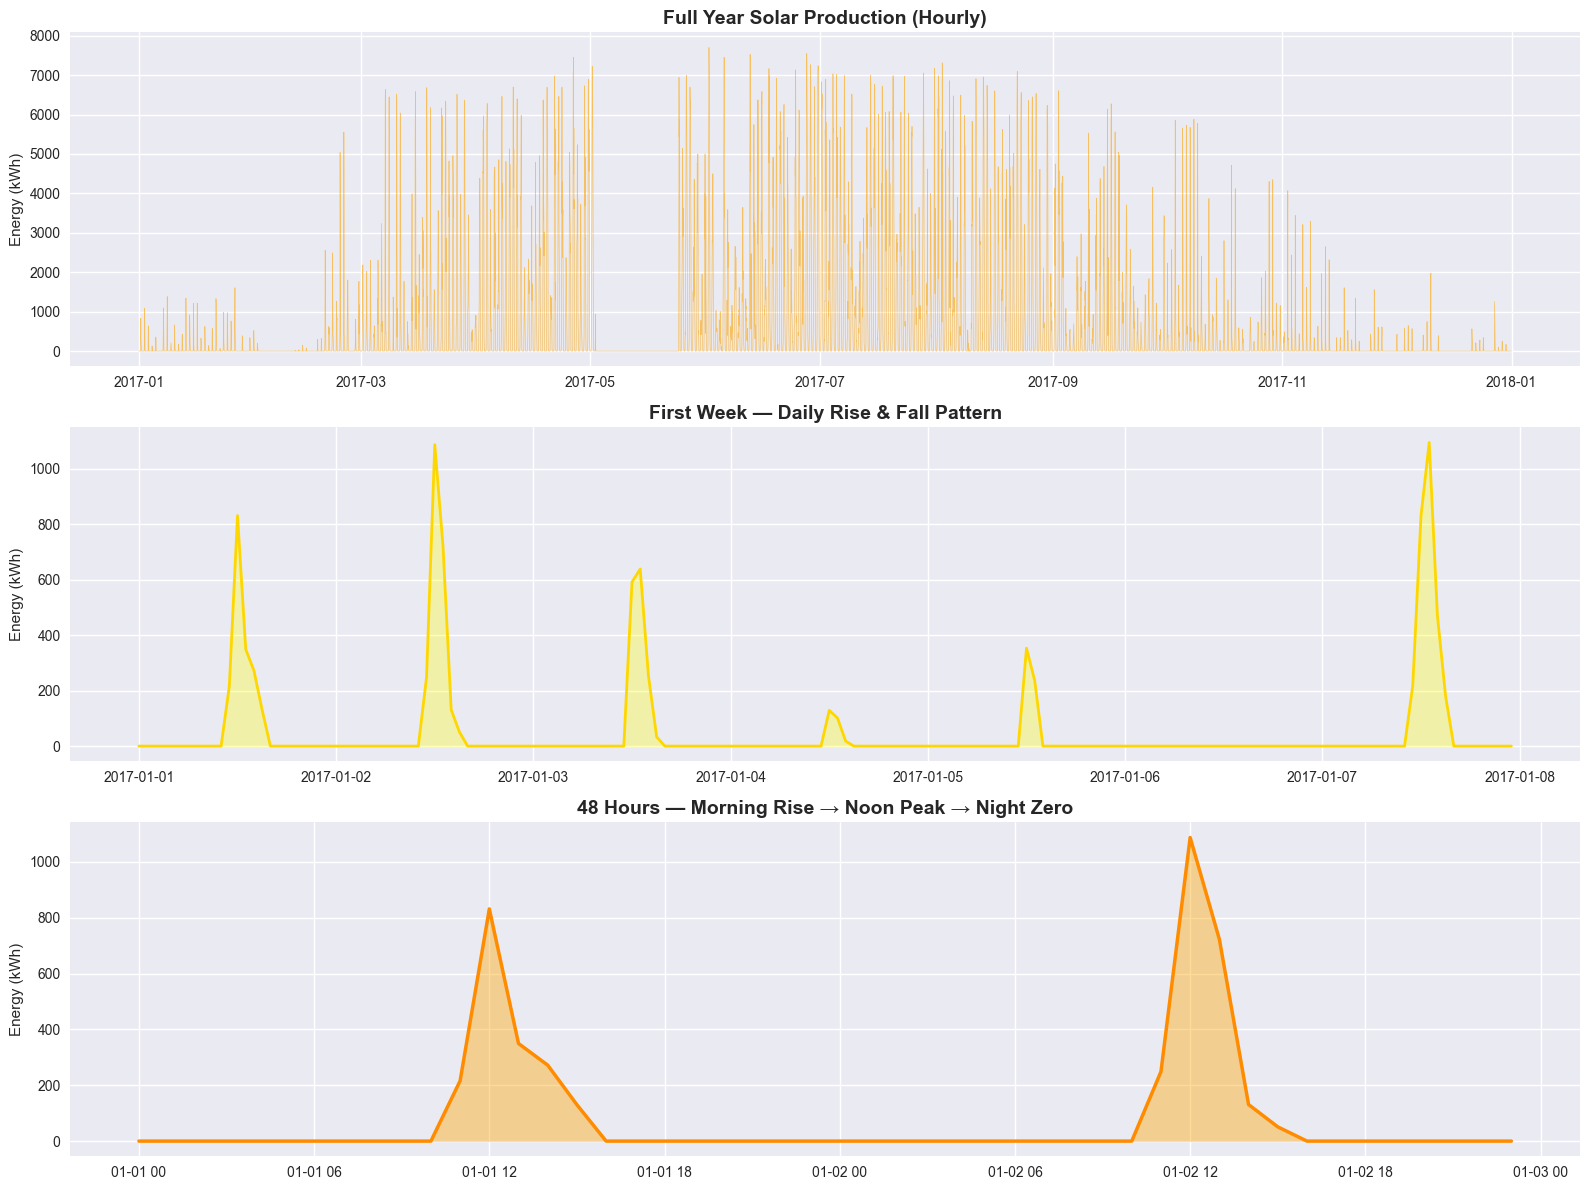

Chart saved to reports/


In [40]:
fig, axes = plt.subplots(3,1,figsize=(16,12))

# Chart-1 Full year
axes[0].plot(df.index, df['SystemProduction'],color='orange',alpha=0.6,linewidth=0.5)
axes[0].set_title("Full Year Solar Production (Hourly)",fontsize=14,fontweight='bold')
axes[0].set_ylabel("Energy (kWh)")

# Chart-2 One week (first 168 hours = 7 days × 24 hours)
week_data = df['SystemProduction'].iloc[:168]
axes[1].plot(week_data.index, week_data.values, color='gold', linewidth=2)
axes[1].set_title("First Week — Daily Rise & Fall Pattern",fontsize=14,fontweight='bold')
axes[1].set_ylabel("Energy (kWh)")
axes[1].fill_between(week_data.index, week_data.values, alpha=0.3, color='yellow')

# Chart 3: 48 hours detail
day_data = df['SystemProduction'].iloc[:48]
axes[2].plot(day_data.index, day_data.values, color='darkorange', linewidth=2.5)
axes[2].set_title('48 Hours — Morning Rise → Noon Peak → Night Zero', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Energy (kWh)')
axes[2].fill_between(day_data.index, day_data.values, alpha=0.4, color='orange')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS, '01_production_over_time.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/")